In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

# Первым шагом на пути к решению является определение того, какие источники данных будут иметь отношение к проблеме.


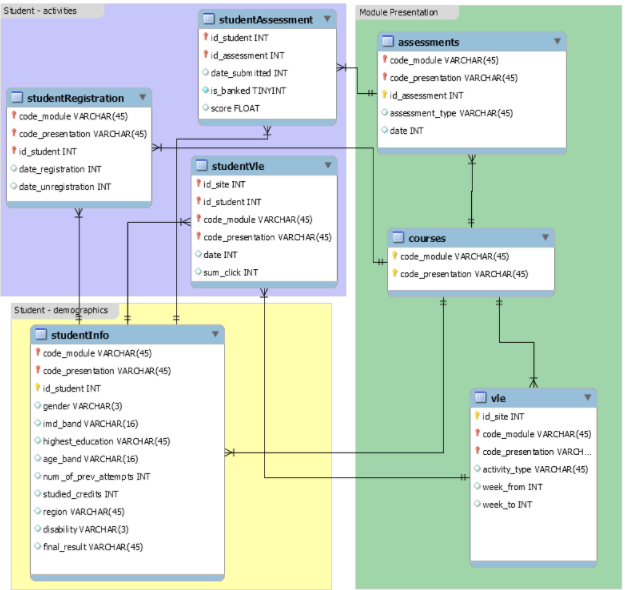


Нужная информация содержится в следующих таблицах:

- studentInfo
- studentAssessment
- assessments
- studentVle
- vle

Эти таблицы будут использованы для процесса построения модели

In [41]:
studInfo=pd.read_csv("data_students/studentInfo.csv")
assessments=pd.read_csv("data_students/assessments.csv")
studAss=pd.read_csv("data_students/studentAssessment.csv")
studVle=pd.read_csv("data_students/studentVle.csv")
vle=pd.read_csv("data_students/vle.csv")

courses = pd.read_csv("data_students/courses.csv")
studentRegistration = pd.read_csv("data_students/studentRegistration.csv")

# Часть 1: Feature Engineering

При построении модели прогнозирования успеваемости студентов важно не просто использовать все доступные признаки, а определить, какие из них действительно влияют на итоговый результат обучения. Избыточные или слабо информативные переменные могут ухудшать качество модели и увеличивать время её обучения. 

## Assessments

Результаты каждого экзамена являются хорошим показателем знаний студентов по курсу, и, поскольку они формируют оценку для итоговой оценки, интересно включить их в итоговую модель. Но, поскольку существует много разных курсов, каждый из которых имеет свою структуру, невозможно создать отдельную функцию для каждой оценки. Чтобы включить оценки, создано 2 функции: одна из них - это итоговая оценка, полученная по баллам, и вес каждой оценки. Другой показатель - это проходной балл, созданный исходя из того, что студент должен набрать не менее 40% баллов по экзамену, чтобы сдать его, рассчитывая процент успешно сданных им оценок. Мы также отделим выпускные экзамены от других оценок, учитывая, что их статус и участие в итоговой оценке отличаются от других оценок.

In [45]:
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [46]:
studAss.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [47]:
studAss.info()
studAss.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

In [48]:
assessments.info()
assessments.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB


code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

In [49]:
assessments["date"] = assessments["date"].fillna(0)
studAss["score"] = studAss["score"].fillna(0)

In [50]:
print(studAss.isna().sum())
print(assessments.isna().sum())

id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64
code_module          0
code_presentation    0
id_assessment        0
assessment_type      0
date                 0
weight               0
dtype: int64


In [51]:
exams=assessments[assessments["assessment_type"]=="Exam"]
others=assessments[assessments["assessment_type"]!="Exam"]
amounts=others.groupby(["code_module","code_presentation"]).count()["id_assessment"] 
amounts=amounts.reset_index()
amounts.head()

#общее кол-во оценок по модулям 

,code_module,code_presentation,id_assessment
0,AAA,2013J,5
1,AAA,2014J,5
2,BBB,2013B,11
3,BBB,2013J,11
4,BBB,2014B,11


In [52]:
#Функция, позволяющая определить, прошел ли учащийся заданную оценку.
def pass_fail(grade):
    if grade>=40:
        return True
    else:
        return False
#Создание фрейма данных stud_ass для объединения информации об оценочных весах и соответствующих оценках
stud_ass_without_exam=pd.merge(studAss,others,how="inner",on=["id_assessment"])
stud_ass_without_exam["pass"]=stud_ass_without_exam["score"].apply(pass_fail)
stud_ass_without_exam["weighted_grade"]=stud_ass_without_exam["score"]*assessments["weight"]/100

In [53]:
stud_ass_without_exam

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,pass,weighted_grade
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,True,7.8
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,True,14.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,True,14.4
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,True,13.8
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,True,23.7
...,...,...,...,...,...,...,...,...,...,...,...,...
168948,37443,527538,227,0,60.0,GGG,2014J,CMA,229.0,0.0,True,NaN
168949,37443,534672,229,0,100.0,GGG,2014J,CMA,229.0,0.0,True,NaN
168950,37443,546286,215,0,80.0,GGG,2014J,CMA,229.0,0.0,True,NaN
168951,37443,546724,230,0,100.0,GGG,2014J,CMA,229.0,0.0,True,NaN


In [54]:
#Средняя итоговая оценка на одного студента за модуль
avg_grade=stud_ass_without_exam.groupby(["id_student","code_module","code_presentation"]).sum()["weighted_grade"].reset_index()
avg_grade.head()

,id_student,code_module,code_presentation,weighted_grade
0,6516,AAA,2014J,0.0
1,8462,DDD,2013J,0.0
2,8462,DDD,2014J,0.0
3,11391,AAA,2013J,7.8
4,23629,BBB,2013B,0.0


In [55]:
avg_grade.shape

(25839, 4)

In [56]:
#pass_rate — это доля сданных заданий студентом по модулю.
pass_rate=pd.merge((stud_ass_without_exam[stud_ass_without_exam["pass"]==True].groupby(["id_student","code_module","code_presentation"]).count()["pass"]).reset_index(),amounts,how="left",on=["code_module","code_presentation"])
pass_rate["pass_rate"]=pass_rate["pass"]/pass_rate["id_assessment"]
pass_rate.drop(["pass","id_assessment"], axis=1,inplace=True)
pass_rate.head()

,id_student,code_module,code_presentation,pass_rate
0,6516,AAA,2014J,1.000000
1,8462,DDD,2013J,0.500000
2,8462,DDD,2014J,0.666667
3,11391,AAA,2013J,1.000000
4,23629,BBB,2013B,0.363636


In [57]:
pass_rate.shape

(25239, 4)

In [58]:
stud_exams = pd.merge(studAss, exams, how="inner", on=["id_assessment"])
stud_exams["exam_score"] = stud_exams["score"]
stud_exams.drop(
    ["id_assessment", "date_submitted", "is_banked", "score", "assessment_type", "date", "weight"],
    axis=1,
    inplace=True
)
stud_exams.head()

,id_student,code_module,code_presentation,exam_score
0,558914,CCC,2014B,32.0
1,559706,CCC,2014B,78.0
2,559770,CCC,2014B,54.0
3,560114,CCC,2014B,64.0
4,560311,CCC,2014B,100.0


In [59]:
stud_exams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4959 entries, 0 to 4958
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         4959 non-null   int64  
 1   code_module        4959 non-null   object 
 2   code_presentation  4959 non-null   object 
 3   exam_score         4959 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 155.1+ KB


In [60]:
# Объединяем показатели оценок
avg_grade_plus_pass_rate = pd.merge(
    avg_grade,
    pass_rate,
    how="outer", #это тип соединения, который возвращает все строки из обеих таблиц, заполняя отсутствующие значения NaN.
    on=["id_student", "code_module", "code_presentation"]
)

In [61]:
avg_grade_plus_pass_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25839 entries, 0 to 25838
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         25839 non-null  int64  
 1   code_module        25839 non-null  object 
 2   code_presentation  25839 non-null  object 
 3   weighted_grade     25839 non-null  float64
 4   pass_rate          25239 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1009.5+ KB


In [62]:
avg_grade_plus_pass_rate.isna().sum()

id_student             0
code_module            0
code_presentation      0
weighted_grade         0
pass_rate            600
dtype: int64

In [63]:
avg_grade_plus_pass_rate["pass_rate"] = avg_grade_plus_pass_rate["pass_rate"].fillna(0)

In [64]:
# Добавляем информацию о количестве экзаменов
assessment_info = pd.merge(
    avg_grade_plus_pass_rate,
    stud_exams,
    how="left",
    on=["id_student", "code_module", "code_presentation"]
)

In [65]:
assessment_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25839 entries, 0 to 25838
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         25839 non-null  int64  
 1   code_module        25839 non-null  object 
 2   code_presentation  25839 non-null  object 
 3   weighted_grade     25839 non-null  float64
 4   pass_rate          25839 non-null  float64
 5   exam_score         4955 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.2+ MB


In [66]:
# Создание бинарного признака "экзамен был  / не был"
assessment_info["exam_taken"] = assessment_info["exam_score"].notna().astype(int)
assessment_info["exam_score_filled"] = assessment_info["exam_score"].fillna(0)
assessment_info.drop(["exam_score"],axis=1,inplace=True)

assessment_info.head(10)

,id_student,code_module,code_presentation,weighted_grade,pass_rate,exam_taken,exam_score_filled
0,6516,AAA,2014J,0.0,1.000000,0,0.0
1,8462,DDD,2013J,0.0,0.500000,0,0.0
2,8462,DDD,2014J,0.0,0.666667,0,0.0
3,11391,AAA,2013J,7.8,1.000000,0,0.0
4,23629,BBB,2013B,0.0,0.363636,0,0.0
5,23698,CCC,2014J,0.0,1.000000,1,80.0
6,23798,BBB,2013J,0.0,1.000000,0,0.0
7,24186,GGG,2014B,0.0,0.888889,0,0.0
8,24213,DDD,2014B,0.0,1.000000,1,58.0
9,24391,GGG,2013J,0.0,1.000000,0,0.0


In [67]:
assessment_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25839 entries, 0 to 25838
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         25839 non-null  int64  
 1   code_module        25839 non-null  object 
 2   code_presentation  25839 non-null  object 
 3   weighted_grade     25839 non-null  float64
 4   pass_rate          25839 non-null  float64
 5   exam_taken         25839 non-null  int64  
 6   exam_score_filled  25839 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB


## VLE

Наборы данных, относящиеся к VLE (виртуальной учебной среде), содержат информацию о взаимодействии учащихся с контентом, доступным для ознакомления в течение всего периода обучения. Исходя из этих данных, мы можем сделать вывод о том, насколько хорошо студент разбирался в своих предметах, тщательно ли он их изучал и как использовал контент.

In [69]:
vle

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN
...,...,...,...,...,...,...
6359,897063,GGG,2014J,resource,NaN,NaN
6360,897109,GGG,2014J,resource,NaN,NaN
6361,896965,GGG,2014J,oucontent,NaN,NaN
6362,897060,GGG,2014J,resource,NaN,NaN


In [70]:
vle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB


In [71]:
vle.isna().sum()

id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64

In [72]:
vle[~vle["week_from"].isna()]
#Только в 1121 из 6364 заявок указана контрольная неделя для материалов (неделя, в течение которой они будут использоваться в курсе).
#Учитывая это, создание показателя для отслеживания приверженности учебе становится непрактичным

,id_site,code_module,code_presentation,activity_type,week_from,week_to
113,546732,AAA,2013J,oucontent,2.0,2.0
198,546719,AAA,2013J,oucontent,1.0,1.0
210,546681,AAA,2013J,oucontent,1.0,1.0
264,877040,AAA,2014J,oucontent,2.0,2.0
323,877045,AAA,2014J,oucontent,1.0,1.0
...,...,...,...,...,...,...
6243,798728,GGG,2014B,resource,1.0,1.0
6266,897051,GGG,2014J,resource,2.0,2.0
6285,897121,GGG,2014J,resource,1.0,1.0
6304,897050,GGG,2014J,resource,1.0,1.0


In [449]:
studVle.describe()

,id_student,id_site,date,sum_click
count,10655280.0000,10655280.0000,10655280.0000,10655280.0000
mean,733333.5669,738323.4164,95.1740,3.7169
std,582705.9825,131219.6222,76.0713,8.8490
min,6516.0000,526721.0000,-25.0000,1.0000
25%,507743.0000,673519.0000,25.0000,1.0000
50%,588236.0000,730069.0000,86.0000,2.0000
75%,646484.0000,877030.0000,156.0000,3.0000
max,2698588.0000,1049562.0000,269.0000,6977.0000


Обычно date — это временная метка (дни относительно начала курса), и усреднение дат имеет смысл только для анализа паттернов поведения.
Средняя дата посещения (date) — показывает, когда в среднем студент посещал этот ресурс (отрицательное = до начала, положительное = после начала)

In [75]:
#Здесь можно отслеживать среднее время, затраченное студентом после начала курса на использование материалов
#и среднее количество кликов по каждому материалу

avg_per_site=studVle.groupby(["id_student","id_site","code_module","code_presentation"]).mean().reset_index()
avg_per_site.head()

,id_student,id_site,code_module,code_presentation,date,sum_click
0,6516,877011,AAA,2014J,210.333333,3.833333
1,6516,877012,AAA,2014J,90.833333,2.310606
2,6516,877015,AAA,2014J,113.461538,2.000000
3,6516,877023,AAA,2014J,122.666667,2.000000
4,6516,877025,AAA,2014J,41.142857,4.333333


In [77]:
#Общий средний показатель на одного студента за модуль
vle_avg_per_student=avg_per_site.groupby(["id_student","code_module","code_presentation"]).mean()[["date","sum_click"]].reset_index()
vle_avg_per_student.head()

,id_student,code_module,code_presentation,date,sum_click
0,6516,AAA,2014J,105.292573,5.816135
1,8462,DDD,2013J,38.794704,1.734524
2,8462,DDD,2014J,10.000000,3.000000
3,11391,AAA,2013J,111.739069,4.231515
4,23629,BBB,2013B,33.409632,2.817316


In [79]:
vle_avg_per_student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         29228 non-null  int64  
 1   code_module        29228 non-null  object 
 2   code_presentation  29228 non-null  object 
 3   date               29228 non-null  float64
 4   sum_click          29228 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.1+ MB


## StudentInfo

Таблица StudentInfo содержит различную информацию о студентах, но для этого анализа важны следующие данные::

* Количество раз, когда студент уже пытался завершить модуль
* Конечный результат студентов

Последняя переменная является нашей переменной интереса при построении нашей модели прогнозирования

In [81]:
studInfo

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


Перевести в среднее значение интервала imd_band

In [84]:
def imd_to_numeric(imd):
    if pd.isna(imd):
        return None  
    start, end = imd.strip('%').split('-') # разбиваю "10-20%" → [10,20] и берём среднее
    return (float(start)+float(end))/2

studInfo["imd_band_numeric"] = studInfo["imd_band"].apply(imd_to_numeric)

mean_imd = studInfo["imd_band_numeric"].mean() # Заполняю NaN средним значением
studInfo["imd_band_numeric"] = studInfo["imd_band_numeric"].fillna(mean_imd)

studInfo[["imd_band","imd_band_numeric"]].head(10)

,imd_band,imd_band_numeric
0,90-100%,95.000000
1,20-30%,25.000000
2,30-40%,35.000000
3,50-60%,55.000000
4,50-60%,55.000000
5,80-90%,85.000000
6,30-40%,35.000000
7,90-100%,95.000000
8,70-80%,75.000000
9,NaN,47.115495


One-hot кодирование для age_band

In [87]:
age_dummies = pd.get_dummies(studInfo["age_band"], prefix="age")
studInfo = pd.concat([studInfo, age_dummies], axis=1)

In [89]:
studInfo.drop(["imd_band" , "age_band"], axis=1,inplace=True) 

In [91]:
studInfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   num_of_prev_attempts  32593 non-null  int64  
 7   studied_credits       32593 non-null  int64  
 8   disability            32593 non-null  object 
 9   final_result          32593 non-null  object 
 10  imd_band_numeric      32593 non-null  float64
 11  age_0-35              32593 non-null  bool   
 12  age_35-55             32593 non-null  bool   
 13  age_55<=              32593 non-null  bool   
dtypes: bool(3), float64(1), int64(3), object(7)
memory usage: 2.8+ MB


## Объединение таблиц

Теперь объединяем всё с studentInfo.

In [94]:
# Добавляем демографические характеристики студентов
df = pd.merge(
    studInfo,
    assessment_info,
    how="left",
    on=["id_student", "code_module", "code_presentation"]
)

# Добавляем агрегированную активность студентов в системе
final_df = pd.merge(
    df,
    vle_avg_per_student, 
    how="left",
    on=["id_student", "code_module", "code_presentation"]
)

In [96]:
vle_avg_per_student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         29228 non-null  int64  
 1   code_module        29228 non-null  object 
 2   code_presentation  29228 non-null  object 
 3   date               29228 non-null  float64
 4   sum_click          29228 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.1+ MB


In [98]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   num_of_prev_attempts  32593 non-null  int64  
 7   studied_credits       32593 non-null  int64  
 8   disability            32593 non-null  object 
 9   final_result          32593 non-null  object 
 10  imd_band_numeric      32593 non-null  float64
 11  age_0-35              32593 non-null  bool   
 12  age_35-55             32593 non-null  bool   
 13  age_55<=              32593 non-null  bool   
 14  weighted_grade        25839 non-null  float64
 15  pass_rate          

Много строк с NaN в оценках и активности, и почти всегда это студенты, которые Withdrawn (отчисленные) или полностью не сдавали материалы. 

In [101]:
final_df.isna().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
imd_band_numeric           0
age_0-35                   0
age_35-55                  0
age_55<=                   0
weighted_grade          6754
pass_rate               6754
exam_taken              6754
exam_score_filled       6754
date                    3365
sum_click               3365
dtype: int64

In [103]:
final_df[final_df['final_result'] =='Withdrawn' ][['final_result', 'weighted_grade',	'pass_rate',	'exam_taken',	'exam_score_filled']]

,final_result,weighted_grade,pass_rate,exam_taken,exam_score_filled
2,Withdrawn,NaN,NaN,NaN,NaN
15,Withdrawn,0.66,0.400000,0.0,0.0
22,Withdrawn,13.32,0.200000,0.0,0.0
29,Withdrawn,0.67,0.600000,0.0,0.0
41,Withdrawn,0.85,0.600000,0.0,0.0
...,...,...,...,...,...
32576,Withdrawn,NaN,NaN,NaN,NaN
32577,Withdrawn,0.00,0.111111,0.0,0.0
32578,Withdrawn,0.00,0.222222,0.0,0.0
32586,Withdrawn,NaN,NaN,NaN,NaN


Заполним так: 
* Withdrawn → все нули
* Если все признаки NaN (студент не участвовал) → нули
* Для остальных студентов (Pass, Fail, Distinction) → NaN заполняются средним по курсу, остальные значения остаются как есть


exam_taken = 0 → студента нет на экзамене
exam_score_filled = 0 → нет баллов
weighted_grade = 0 → не выполнено задание
withdrawn = 1 → сигнал модели, что студент ушёл

Таким образом, модель сможет различать отсутствие активности и реально низкие оценки.

In [106]:
# Список колонок, которые буду заполнятся
cols_to_fill = ["weighted_grade", "pass_rate", "exam_taken", "exam_score_filled", "date", "sum_click"]

# бинарный признак Withdrawn
final_df["withdrawn"] = (final_df["final_result"] == "Withdrawn").astype(int)

def fill_by_status(row):
    if row["withdrawn"] == 1:
        return [0]*len(cols_to_fill)
    
    # Если все признаки NaN → тоже нулями
    if all(pd.isna(row[col]) for col in cols_to_fill):
        return [0]*len(cols_to_fill)
    
    # Иначе: для каждого столбца, если NaN → среднее по курсу
    filled_values = []
    for col in cols_to_fill:
        if pd.notna(row[col]):
            filled_values.append(row[col])
        else:
            # среднее по курсу (code_module + code_presentation)
            course_mean = final_df[
                (final_df["code_module"] == row["code_module"]) &
                (final_df["code_presentation"] == row["code_presentation"])
            ][col].mean()
            filled_values.append(course_mean)
    return filled_values

filled_array = final_df.apply(fill_by_status, axis=1, result_type='expand')
filled_array.columns = cols_to_fill
final_df[cols_to_fill] = filled_array

#final_df[["final_result"]== + cols_to_fill + ["withdrawn"]].head(10)
final_df[(final_df["final_result"] == "Withdrawn") | (final_df["final_result"] == "Fail")][cols_to_fill + ["final_result"]].head(10)

,weighted_grade,pass_rate,exam_taken,exam_score_filled,date,sum_click,final_result
2,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
15,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
18,3.0,0.6,0.0,0.0,87.003727,1.496894,Fail
22,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
29,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
41,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
44,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
45,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
48,0.0,0.0,0.0,0.0,0.000000,0.000000,Withdrawn
52,10.4,1.0,0.0,0.0,100.588023,2.607610,Fail


In [107]:
final_df.isna().sum()

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
imd_band_numeric        0
age_0-35                0
age_35-55               0
age_55<=                0
weighted_grade          0
pass_rate               0
exam_taken              0
exam_score_filled       0
date                    0
sum_click               0
withdrawn               0
dtype: int64

In [108]:
final_df

,code_module,code_presentation,id_student,gender,region,highest_education,num_of_prev_attempts,studied_credits,disability,final_result,...,age_0-35,age_35-55,age_55<=,weighted_grade,pass_rate,exam_taken,exam_score_filled,date,sum_click,withdrawn
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,0,240,N,Pass,...,False,False,True,7.8,1.000000,0.0,0.0,111.739069,4.231515,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,0,60,N,Pass,...,False,True,False,14.0,1.000000,0.0,0.0,92.532356,3.541379,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,0,60,Y,Withdrawn,...,False,True,False,0.0,0.000000,0.0,0.0,0.000000,0.000000,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,0,60,N,Pass,...,False,True,False,14.4,1.000000,0.0,0.0,99.678124,3.658979,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,0,60,N,Pass,...,True,False,False,13.8,0.600000,0.0,0.0,99.220225,2.821116,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,0,30,N,Fail,...,True,False,False,0.0,0.786240,0.0,0.0,15.537500,1.675000,0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,0,30,N,Distinction,...,False,True,False,0.0,1.000000,0.0,0.0,145.923861,4.146087,0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,0,30,Y,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,116.294414,2.874623,0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,0,30,N,Withdrawn,...,False,True,False,0.0,0.000000,0.0,0.0,0.000000,0.000000,1


# Часть 2: EDA

Предварительный анализ данных с проверки целостности фрейма данных

In [134]:
print("Shape:", final_df.shape)
final_df.info()

Shape: (32593, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   num_of_prev_attempts  32593 non-null  int64  
 7   studied_credits       32593 non-null  int64  
 8   disability            32593 non-null  object 
 9   final_result          32593 non-null  object 
 10  imd_band_numeric      32593 non-null  float64
 11  age_0-35              32593 non-null  bool   
 12  age_35-55             32593 non-null  bool   
 13  age_55<=              32593 non-null  bool   
 14  weighted_grade        32593 non-null  float64
 15  

Проведён анализ пропущенных значений. Большинство признаков не содержат пропусков, что свидетельствует о высокой целостности данных. Отдельные пропуски были обработаны на этапе предобработки.

In [112]:
final_df.duplicated().sum()

0

In [114]:
final_df["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

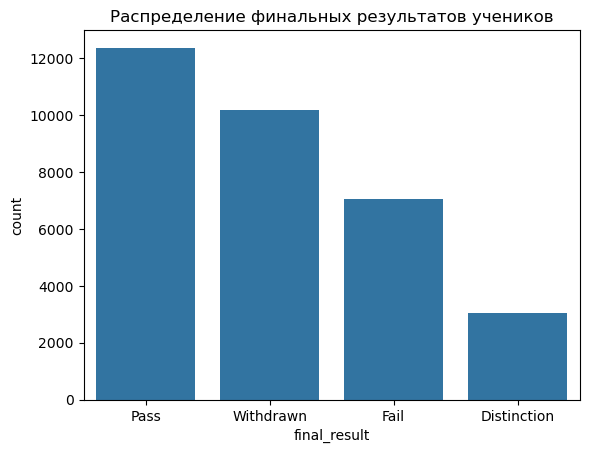

In [116]:
sns.countplot(x="final_result", data=final_df)
plt.title("Распределение финальных результатов учеников")
plt.show()

Переменная withdrawn отражает факт досрочного прекращения обучения и может использоваться для задач раннего выявления студентов группы риска.

Числовые признаки имеют различный масштаб значений, что требует нормализации при использовании моделей, чувствительных к масштабу данных.

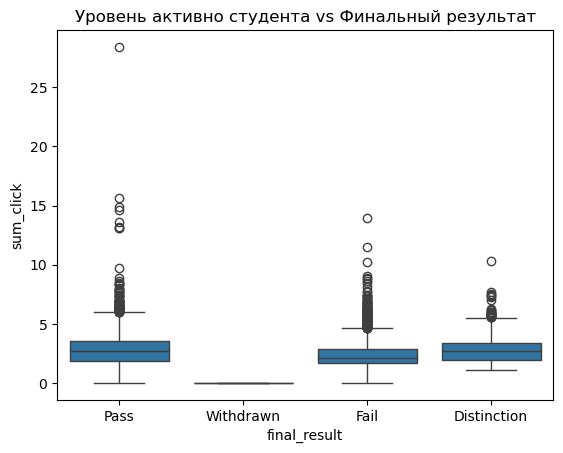

In [118]:
sns.boxplot(x="final_result", y="sum_click", data=final_df)
plt.title("Уровень активно студента vs Финальный результат")
plt.show()

In [120]:
final_df

,code_module,code_presentation,id_student,gender,region,highest_education,num_of_prev_attempts,studied_credits,disability,final_result,...,age_0-35,age_35-55,age_55<=,weighted_grade,pass_rate,exam_taken,exam_score_filled,date,sum_click,withdrawn
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,0,240,N,Pass,...,False,False,True,7.8,1.000000,0.0,0.0,111.739069,4.231515,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,0,60,N,Pass,...,False,True,False,14.0,1.000000,0.0,0.0,92.532356,3.541379,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,0,60,Y,Withdrawn,...,False,True,False,0.0,0.000000,0.0,0.0,0.000000,0.000000,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,0,60,N,Pass,...,False,True,False,14.4,1.000000,0.0,0.0,99.678124,3.658979,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,0,60,N,Pass,...,True,False,False,13.8,0.600000,0.0,0.0,99.220225,2.821116,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,0,30,N,Fail,...,True,False,False,0.0,0.786240,0.0,0.0,15.537500,1.675000,0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,0,30,N,Distinction,...,False,True,False,0.0,1.000000,0.0,0.0,145.923861,4.146087,0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,0,30,Y,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,116.294414,2.874623,0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,0,30,N,Withdrawn,...,False,True,False,0.0,0.000000,0.0,0.0,0.000000,0.000000,1


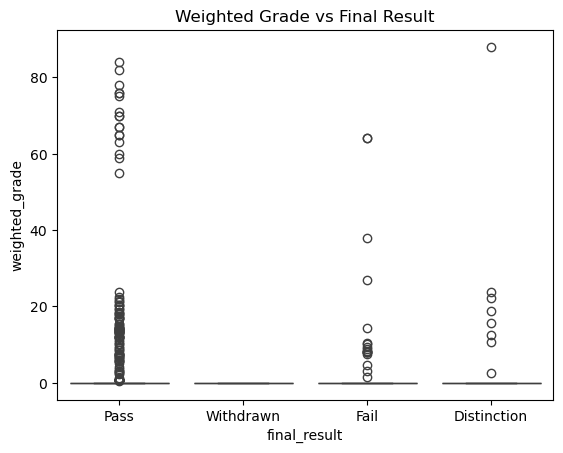

In [122]:
sns.boxplot(x="final_result", y="weighted_grade", data=final_df)
plt.title("Weighted Grade vs Final Result")
plt.show()

Целевой признак является категориальным - это не позволяет нам включить его в корреляционную матрицу, но мы можем видеть тенденцию корреляции между другими признаками.

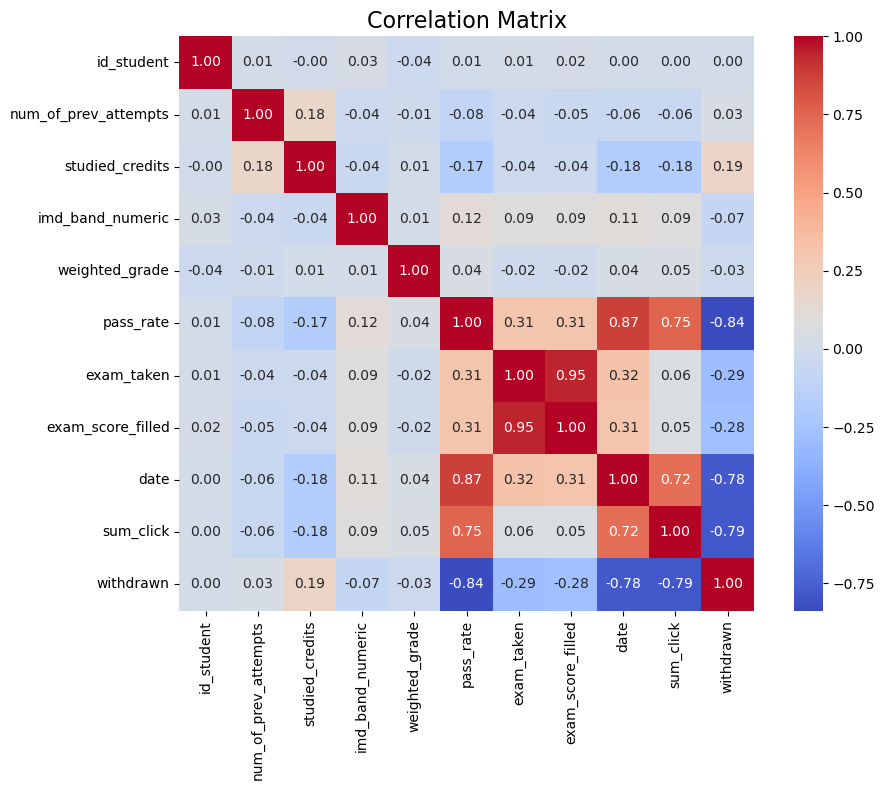

In [125]:
# Выбираем только числовые признаки для корреляции
numeric_df = final_df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

Для понимания структуры данных необходимо изучить распределения переменных. Распределения признаков показывают наличие асимметрии, особенно для показателей активности студентов (sum_click) и количества предыдущих попыток.

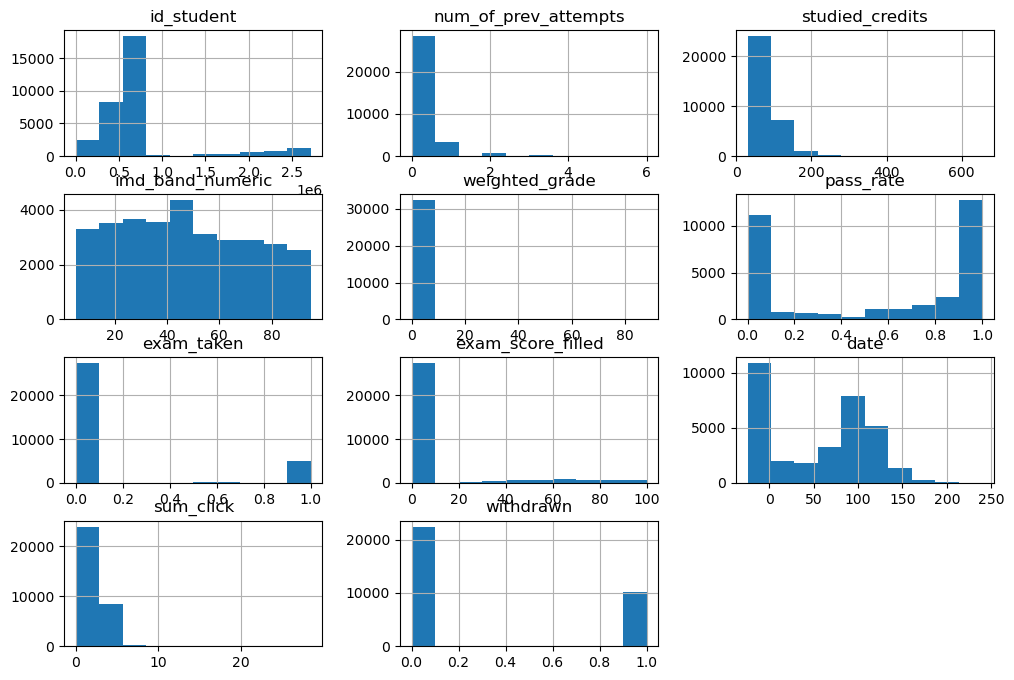

In [128]:
final_df.hist(figsize=(12,8))
plt.show()

В ходе предварительного анализа были выявлены отдельные наблюдения с повышенными значениями активности студентов в системе дистанционного обучения (sum_click) и большим количеством предыдущих попыток прохождения курса (num_of_prev_attempts).

Однако данные значения отражают реальные особенности поведения отдельных студентов и не являются ошибками измерения. В связи с этим было принято решение сохранить данные наблюдения в выборке для дальнейшего анализа, поскольку они могут представлять интерес для задач мониторинга и прогнозирования академической успеваемости.

<Axes: xlabel='sum_click'>

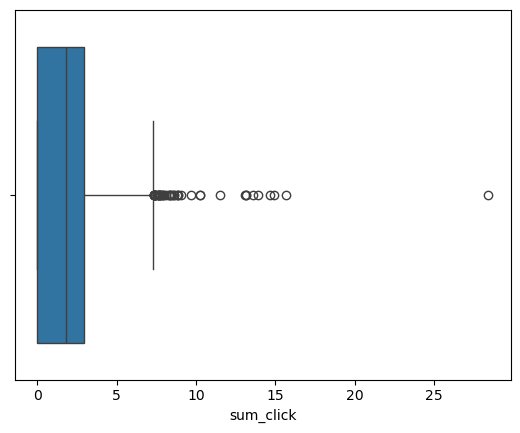

In [130]:
sns.boxplot(x=final_df["sum_click"])

In [132]:
final_df[final_df["sum_click"] > 10]

,code_module,code_presentation,id_student,gender,region,highest_education,num_of_prev_attempts,studied_credits,disability,final_result,...,age_0-35,age_35-55,age_55<=,weighted_grade,pass_rate,exam_taken,exam_score_filled,date,sum_click,withdrawn
264,AAA,2013J,1894188,F,East Midlands Region,A Level or Equivalent,0,60,N,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,84.527759,13.086678,0
1368,BBB,2013B,504014,F,Wales,Lower Than A Level,0,120,N,Fail,...,False,True,False,0.0,0.181818,0.0,0.0,20.575032,10.258204,0
6733,BBB,2014J,520972,F,Scotland,HE Qualification,1,60,N,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,91.746036,13.591237,0
6931,BBB,2014J,584733,F,South West Region,Lower Than A Level,0,60,N,Distinction,...,True,False,False,0.0,0.800000,0.0,0.0,94.046272,10.284659,0
7302,BBB,2014J,642122,F,Scotland,HE Qualification,0,60,N,Pass,...,False,True,False,0.0,1.000000,0.0,0.0,51.483802,14.905136,0
8840,CCC,2014B,285170,M,London Region,A Level or Equivalent,0,60,N,Pass,...,False,True,False,0.0,0.875000,1.0,74.0,137.702513,13.134308,0
20191,EEE,2013J,601224,M,Scotland,HE Qualification,0,90,N,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,93.652794,28.440018,0
20402,EEE,2013J,2616950,M,North Region,A Level or Equivalent,0,60,N,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,99.218705,13.148052,0
23302,FFF,2013B,543643,F,South Region,A Level or Equivalent,0,60,Y,Pass,...,True,False,False,0.0,1.000000,0.0,0.0,86.947045,14.658266,0
28576,FFF,2014J,635079,M,Scotland,A Level or Equivalent,1,60,N,Fail,...,False,True,False,0.0,0.719072,0.0,0.0,21.000000,11.500000,0


In [156]:
final_df.describe()

,id_student,num_of_prev_attempts,studied_credits,imd_band_numeric,weighted_grade,pass_rate,exam_taken,exam_score_filled,date,sum_click,withdrawn
count,2.607400e+04,26074.000000,26074.000000,26074.000000,26074.000000,26074.000000,26074.000000,26074.000000,26074.000000,26074.000000,26074.000000
mean,7.077295e+05,0.164723,79.801718,47.124608,0.077588,0.548651,0.155404,10.190618,59.866662,1.812074,0.311613
std,5.517794e+05,0.483832,41.277971,27.682578,1.857610,0.441134,0.359699,24.901223,51.709635,1.536219,0.463162
min,3.733000e+03,0.000000,30.000000,5.000000,0.000000,0.000000,0.000000,0.000000,-24.416667,0.000000,0.000000
25%,5.080612e+05,0.000000,60.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.900590e+05,0.000000,60.000000,45.000000,0.000000,0.750000,0.000000,0.000000,72.212050,1.821828,0.000000
75%,6.449922e+05,0.000000,120.000000,75.000000,0.000000,1.000000,0.000000,0.000000,103.661576,2.924024,1.000000
max,2.716795e+06,6.000000,655.000000,95.000000,88.000000,1.000000,1.000000,100.000000,239.947024,28.440018,1.000000



В ходе предварительного анализа числовых признаков было выявлено, что они имеют существенно различающиеся диапазоны значений (таблица ниже).

| Признак              | Минимум | Максимум | Диапазон    |
| -------------------- | ------- | -------- | ----------- |
| num_of_prev_attempts | 0       | 6        | очень малый |
| pass_rate            | 0       | 1        | малый       |
| weighted_grade       | 0       | 88       | средний     |
| exam_score_filled    | 0       | 100      | средний     |
| sum_click            | 0       | 28.44    | малый       |
| date                 | -24.4   | 239.9    | большой     |


Анализ показывает, что признаки имеют различные масштабы, что может негативно влиять на обучение моделей, чувствительных к масштабу данных.

Особое внимание следует уделить признаку date, который имеет значительно больший диапазон значений и, следовательно, может доминировать в линейных моделях, искажая вклад других признаков.

In [162]:
quantiles = final_df['num_of_prev_attempts'].quantile([0.25, 0.5, 0.75])

print(quantiles)

0.25    0.0
0.50    0.0
0.75    0.0
Name: num_of_prev_attempts, dtype: float64


В ходе анализа данных была выявлена особенность признака num_of_prev_attempts. Это означает, что более 75% студентов не имеют предыдущих попыток прохождения курса, что делает данный признак сильно несбалансированным.

Несмотря на это, признак был сохранён, так как он может содержать полезную информацию для отдельных категорий студентов.

# Часть 3: Modeling

Цель данного этапа — построить модели машинного обучения для прогнозирования академической успеваемости студентов на основе характеристик их учебной активности и результатов промежуточного оценивания.

модель должна предсказывать
| класс       | значение           |
| ----------- | ------------------ |
| Distinction | отличный результат  |
| Pass        | зачет |
| Fail        | незачет         |
| Withdrawn   | отчисление         |





В датасете есть очень сильный leakage признак, который может сильно завысить accuracy модели. Это: exam_score
Почти все модели будут предсказывать результат почти идеально, потому что экзамен почти определяет итог.
Очень часто в исследованиях делают две модели: with exam_score и without exam_score

Чтобы показать реальную predictive power LMS data.

In [285]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import make_scorer, f1_score, recall_score

Для построения моделей были выбраны алгоритмы, представляющие различные подходы машинного обучения: линейные модели, статистические методы, ансамблевые алгоритмы и нейронные сети.

| модель              | причина                      |
| ------------------- | ---------------------------- |
| Logistic Regression | базовая линейная модель      |
| LDA                 | статистический классификатор |
| Random Forest       | ансамблевый метод            |
| Neural Network      | нелинейная модель            |


**Scaling - Нормализация данных/ Масштабирование**

Для моделей, чувствительных к масштабу признаков.
В связи с различием масштабов признаков для моделей, чувствительных к масштабу данных, была применена процедура нормализации с использованием метода Min-Max масштабирования.

Данная трансформация приводит все признаки к диапазону: [0, 1]

что обеспечивает:

* более стабильное обучение моделей
* корректное сравнение весов признаков
* повышение качества предсказаний

Нормализация применялась для следующих моделей:

* Logistic Regression
* Linear Discriminant Analysis
* Neural Network

Для ансамблевых методов, таких как Random Forest, нормализация не применялась, поскольку данные алгоритмы не чувствительны к масштабу признаков.

$$
\text{precision} = \frac{TP}{TP + FP}
$$

$$
\text{recall} = \frac{TP}{TP + FN}
$$

$$
\text{F1-measure} = \frac{2 * \text{precision} * \text{recall}}{\text{precision} + \text{recall}} = \frac{2 * TP}{2 * TP + FP + FN}
$$
 


========== WITH EXAM SCORE ==========


--- LogisticRegression ---
Best params: {'model__C': 10, 'model__class_weight': None}
              precision    recall  f1-score   support

 Distinction       0.81      0.25      0.38       605
        Fail       0.93      0.82      0.87      1411
        Pass       0.77      0.95      0.85      2472
   Withdrawn       1.00      1.00      1.00      2031

    accuracy                           0.87      6519
   macro avg       0.88      0.75      0.77      6519
weighted avg       0.88      0.87      0.86      6519



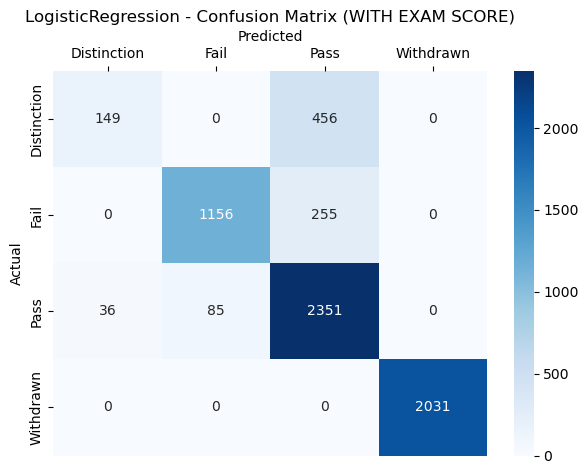


--- LDA ---
Best params: {'model__solver': 'svd'}
              precision    recall  f1-score   support

 Distinction       0.58      0.30      0.39       605
        Fail       0.94      0.64      0.76      1411
        Pass       0.75      0.92      0.83      2472
   Withdrawn       0.92      1.00      0.96      2031

    accuracy                           0.83      6519
   macro avg       0.80      0.71      0.73      6519
weighted avg       0.83      0.83      0.81      6519



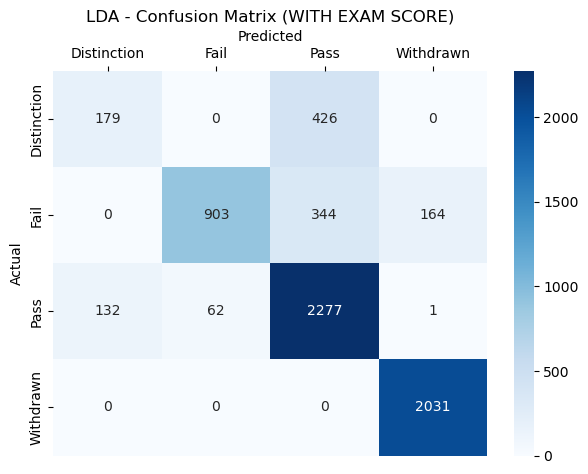


--- RandomForest ---
Best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
              precision    recall  f1-score   support

 Distinction       0.82      0.25      0.39       605
        Fail       0.95      0.82      0.88      1411
        Pass       0.77      0.96      0.86      2472
   Withdrawn       1.00      1.00      1.00      2031

    accuracy                           0.88      6519
   macro avg       0.88      0.76      0.78      6519
weighted avg       0.89      0.88      0.86      6519



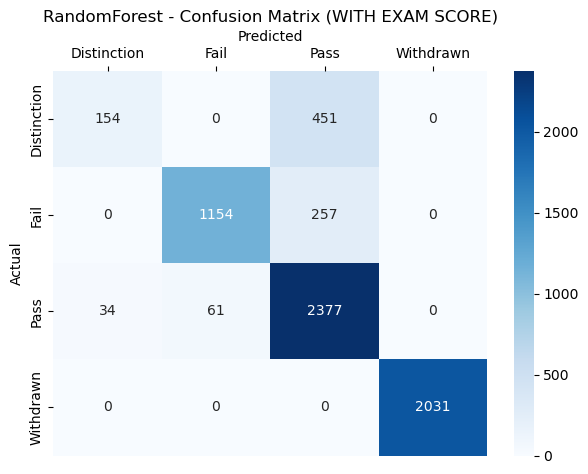


--- NeuralNetwork ---
Best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (50,)}
              precision    recall  f1-score   support

 Distinction       0.74      0.28      0.40       605
        Fail       0.91      0.84      0.87      1411
        Pass       0.78      0.93      0.85      2472
   Withdrawn       1.00      1.00      1.00      2031

    accuracy                           0.87      6519
   macro avg       0.86      0.76      0.78      6519
weighted avg       0.87      0.87      0.86      6519



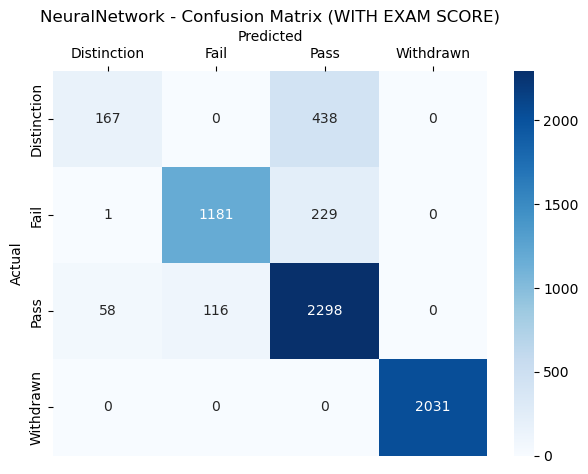


========== WITHOUT EXAM SCORE ==========


--- LogisticRegression ---
Best params: {'model__C': 10, 'model__class_weight': 'balanced'}
              precision    recall  f1-score   support

 Distinction       0.28      0.66      0.39       605
        Fail       0.85      0.80      0.83      1411
        Pass       0.76      0.54      0.63      2472
   Withdrawn       1.00      1.00      1.00      2031

    accuracy                           0.75      6519
   macro avg       0.72      0.75      0.71      6519
weighted avg       0.81      0.75      0.77      6519



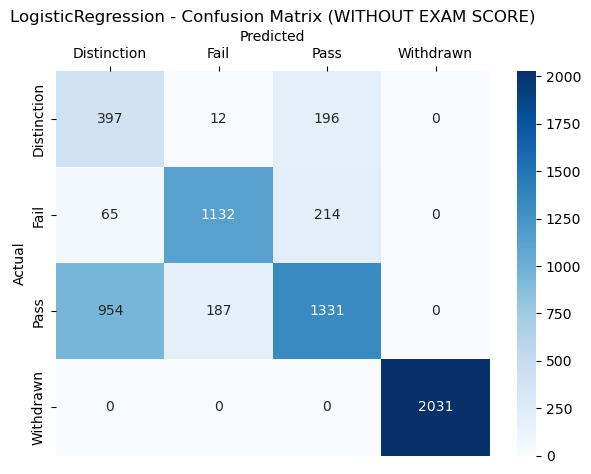


--- LDA ---
Best params: {'model__solver': 'svd'}
              precision    recall  f1-score   support

 Distinction       0.68      0.04      0.08       605
        Fail       0.93      0.61      0.74      1411
        Pass       0.72      0.97      0.82      2472
   Withdrawn       0.92      1.00      0.96      2031

    accuracy                           0.82      6519
   macro avg       0.81      0.66      0.65      6519
weighted avg       0.82      0.82      0.78      6519



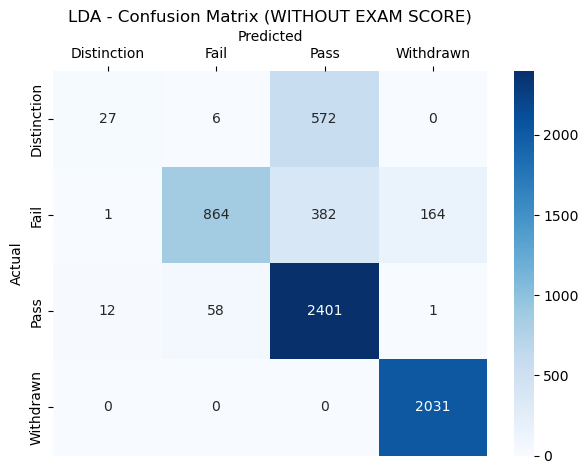


--- RandomForest ---
Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
              precision    recall  f1-score   support

 Distinction       0.51      0.07      0.12       605
        Fail       0.93      0.75      0.83      1411
        Pass       0.72      0.95      0.82      2472
   Withdrawn       1.00      1.00      1.00      2031

    accuracy                           0.84      6519
   macro avg       0.79      0.69      0.69      6519
weighted avg       0.83      0.84      0.81      6519



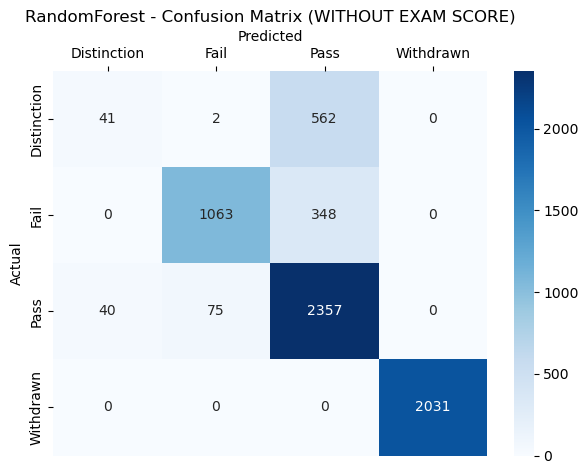


--- NeuralNetwork ---
Best params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100,)}
              precision    recall  f1-score   support

 Distinction       0.35      0.15      0.21       605
        Fail       0.89      0.77      0.83      1411
        Pass       0.73      0.88      0.80      2472
   Withdrawn       1.00      1.00      1.00      2031

    accuracy                           0.83      6519
   macro avg       0.74      0.70      0.71      6519
weighted avg       0.81      0.83      0.81      6519



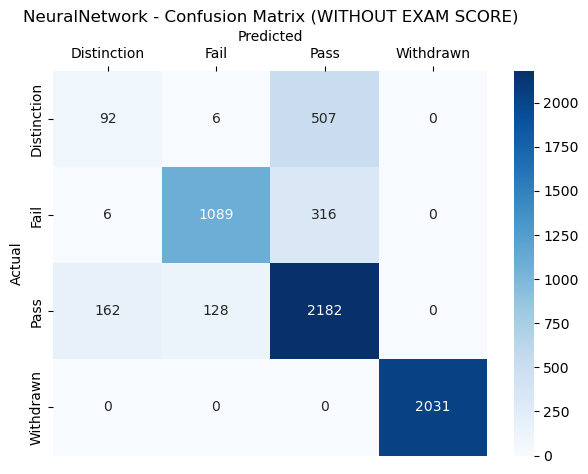


=== MODEL COMPARISON ===

                Model  F1_with_exam  F1_without_exam
0  LogisticRegression        0.7695           0.7089
1                 LDA        0.7290           0.6442
2        RandomForest        0.7738           0.6888
3       NeuralNetwork        0.7755           0.7065


In [363]:
# 1. Целевая переменная
y = final_df["final_result"]

# 2. FEATURE SETS (with and without leakage)
X_full = final_df.drop("final_result", axis=1)
X_no_exam = X_full.drop("exam_score_filled", axis=1)

# 3. Определение признаков 
categorical_features = [
    "gender",
    "region",
    "highest_education",
    "disability",
    "code_module",
    "code_presentation"
]

numeric_features_full = [col for col in X_full.columns if col not in categorical_features]
numeric_features_no_exam = [col for col in X_no_exam.columns if col not in categorical_features]

# 4. Предобработка
preprocessor_full = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features_full),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])
preprocessor_no_exam = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features_no_exam),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# 5. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_no_exam, X_test_no_exam, _, _ = train_test_split(
    X_no_exam, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 6. CROSS VALIDATION
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 7. MODELS + GRIDS
models = {

    "LogisticRegression": (
        LogisticRegression(max_iter=5000),
        {
            "model__C":[0.1,1,10],
            "model__class_weight":[None,"balanced"]
        }
    ),

    "LDA": (
        LinearDiscriminantAnalysis(),
        {
            "model__solver":["svd","lsqr"]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            "model__n_estimators":[100,200],
            "model__max_depth":[None,10],
            "model__min_samples_split":[2,5]
        }
    ),

    "NeuralNetwork": (
        MLPClassifier(max_iter=1000),
        {
            "model__hidden_layer_sizes":[(50,), (100,), (50,50)],
            "model__alpha":[0.0001,0.001]
        }
    )
}

# 8. TRAINING FUNCTION
def train_and_evaluate(X_train, X_test, preprocessor, title):
    
    print(f"\n========== {title} ==========\n")

    results = {}
    best_models = {} 

    for name, (model, params) in models.items():

        print(f"\n--- {name} ---")
        
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model)
        ])

        grid = GridSearchCV(
            pipe,
            params,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        best_models[name] = best_model 

        # Метрики
        print("Best params:", grid.best_params_)
        print(classification_report(y_test, y_pred))

        # CONFUSION MATRIX + HEATMAP
        cm = confusion_matrix(y_test, y_pred)
        
        labels = sorted(y_test.unique()) 
        
        plt.figure(figsize=(7,5))
        ax = sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels
        )
        
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        
        # X-axis наверх
        ax.xaxis.set_label_position('top')
        ax.xaxis.tick_top()
        
        plt.title(f"{name} - Confusion Matrix ({title})")
        
        plt.show()

        results[name] = grid.best_score_

    return results, best_models 

# 9. Запускаем модели
results_full, best_models_full = train_and_evaluate(
    X_train, X_test, preprocessor_full, "WITH EXAM SCORE"
)

results_no_exam, best_models_no_exam = train_and_evaluate(
    X_train_no_exam, X_test_no_exam, preprocessor_no_exam, "WITHOUT EXAM SCORE"
)

# 10. Сравнение
results_df = pd.DataFrame({
    "Model": list(results_full.keys()),
    "F1_with_exam": list(results_full.values()),
    "F1_without_exam": list(results_no_exam.values())
})

print("\n=== MODEL COMPARISON ===\n")
print(results_df)

## Бинарная модель

In [377]:
final_df_binary = final_df.copy()
final_df_binary["target"] = final_df_binary["final_result"].apply(
    lambda x: "AtRisk" if x in ["Fail", "Withdrawn"] else "Success"
)
X = final_df_binary.drop(["final_result", "target", 'exam_score_filled'], axis=1)
y = final_df_binary["target"]

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42 )

categorical_features = [
    "gender", "region", "highest_education",
    "disability", "code_module", "code_presentation"
]

numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


f1_atrisk = make_scorer(f1_score, pos_label="AtRisk")
recall_atrisk = make_scorer(recall_score, pos_label="AtRisk")

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced"]
}

grid_binary = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring=recall_atrisk, 
    n_jobs=-1
)


grid_binary.fit(X_train_binary, y_train_binary)


best_model_binary = grid_binary.best_estimator_
y_pred_binary = best_model_binary.predict(X_test_binary)

print("Best params:", grid_binary.best_params_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))

Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Confusion Matrix:
[[3116  326]
 [  63 3014]]

Classification Report:
              precision    recall  f1-score   support

      AtRisk       0.98      0.91      0.94      3442
     Success       0.90      0.98      0.94      3077

    accuracy                           0.94      6519
   macro avg       0.94      0.94      0.94      6519
weighted avg       0.94      0.94      0.94      6519



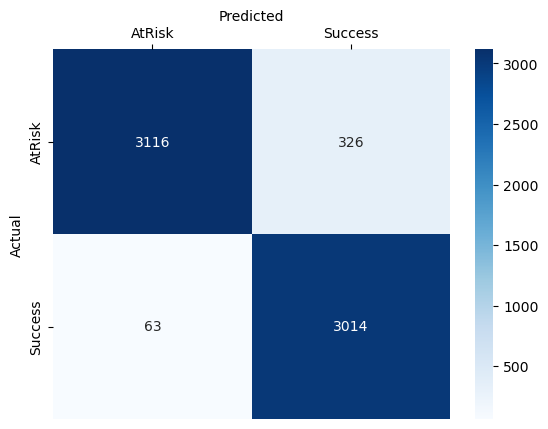

In [378]:
labels = ['AtRisk', 'Success']

cm = confusion_matrix(y_test_binary, y_pred_binary, labels=labels)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", 
            xticklabels=labels, yticklabels=labels)

plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## probability — вероятность каждого класса

Помимо конечного ответа, модель может показать насколько она уверена в каждом варианте.

Многоклассовые предсказания

In [364]:
best_model_multi = best_models_full["RandomForest"]

y_pred_multi = best_model_multi.predict(X_test)
proba_multi = best_model_multi.predict_proba(X_test)

proba_multi_df = pd.DataFrame(proba_multi, columns=best_model_multi.classes_)

pd.set_option('display.float_format', '{:.4f}'.format)
proba_multi_df

,Distinction,Fail,Pass,Withdrawn
0,0.0424,0.8507,0.1018,0.0050
1,0.2843,0.1364,0.5792,0.0000
2,0.0010,0.9875,0.0065,0.0050
3,0.0000,0.0000,0.0000,1.0000
4,0.0098,0.2573,0.7330,0.0000
...,...,...,...,...
6514,0.0000,0.0000,0.0000,1.0000
6515,0.0243,0.0878,0.8880,0.0000
6516,0.0432,0.1336,0.8231,0.0000
6517,0.1440,0.1226,0.7333,0.0000


Бинарные предсказания

In [369]:
proba = best_model_binary.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=best_model_binary.classes_)
proba_df.head()

,AtRisk,Success
0,0.9703,0.0297
1,0.1355,0.8645
2,0.9980,0.0020
3,1.0000,0.0000
4,0.5354,0.4646


Вероятности позволяют построить систему раннего предупреждения студентов группы риска.

Например:
| студент   | вероятность провала | действие                                  |
| --------- | ------------------- | ----------------------------------------- |
| student_1 | 0.82                | преподавателю отправляется предупреждение |
| student_2 | 0.65                | требуется дополнительная проверка         |
| student_3 | 0.12                | всё нормально                             |


/var/folders/yh/j06phdms5x963tdwwj10t2q00000gn/T/ipykernel_26797/3303288832.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


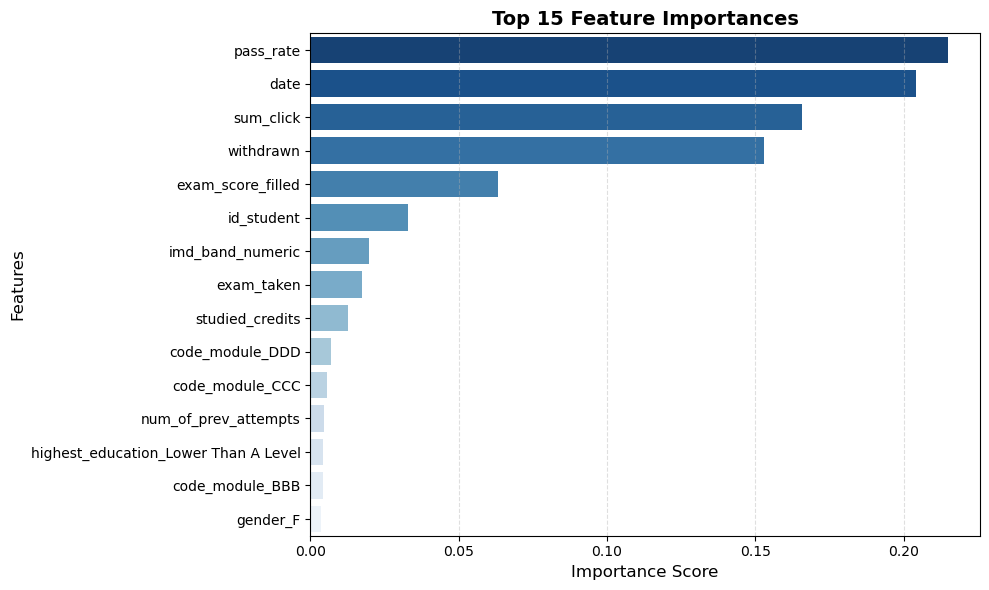

In [406]:
# получаем важности признаков
importances = best_model_multi.named_steps["model"].feature_importances_
feature_names = best_model_multi.named_steps["prep"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

# top 15 признаков
top_n = 15
top_features = feature_importance.head(top_n)

#  график
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title("Top 15 Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show();

Первоначальный анализ важности признака показал, что ключевыми факторами оценки были pass_rate, date, withdrawn и exam_score_filled. Однако эти переменные содержат информацию, полученную на поздней стадии процесса обучения, и могут привести к утечке данных. Для поддержки раннего выявления рисков среди учащихся эти функции следует исключить из модели раннего предупреждения, гарантируя, что прогнозы будут основываться только на информации, доступной до получения окончательного результата.

# Часть 4: Импортируем в opensearch

Финальный dataset для OpenSearch

In [384]:
# копируем тестовые признаки
opensearch_df = X_test.reset_index(drop=True).copy()

# реальные значения multiclass
opensearch_df["true_result"] = y_test.reset_index(drop=True)
opensearch_df["predicted_result"] = y_pred_multi

# вероятности multiclass
for col in proba_multi_df.columns:
    opensearch_df[f"proba_{col}"] = proba_multi_df[col]

# binary prediction
binary_pred = best_model_binary.predict(X_test)
opensearch_df["predicted_risk"] = binary_pred
for col in proba_df.columns:
    opensearch_df[f"risk_proba_{col}"] = proba_df[col]

print(opensearch_df.shape)
opensearch_df.head()

(6519, 29)


,code_module,code_presentation,id_student,gender,region,highest_education,num_of_prev_attempts,studied_credits,disability,imd_band_numeric,...,withdrawn,true_result,predicted_result,proba_proba_Distinction,proba_proba_Fail,proba_proba_Pass,proba_proba_Withdrawn,predicted_risk,risk_proba_AtRisk,risk_proba_Success
0,GGG,2014B,626317,F,South West Region,Lower Than A Level,0,30,Y,45.0000,...,0,Fail,Fail,0.0424,0.8507,0.1018,0.0050,AtRisk,0.9703,0.0297
1,BBB,2013J,105527,F,Scotland,HE Qualification,0,120,N,45.0000,...,0,Pass,Pass,0.2843,0.1364,0.5792,0.0000,Success,0.1355,0.8645
2,FFF,2014J,648190,M,North Region,Lower Than A Level,0,120,N,15.0000,...,0,Fail,Fail,0.0010,0.9875,0.0065,0.0050,AtRisk,0.9980,0.0020
3,FFF,2014J,590381,M,East Anglian Region,Lower Than A Level,0,120,N,25.0000,...,1,Withdrawn,Withdrawn,0.0000,0.0000,0.0000,1.0000,AtRisk,1.0000,0.0000
4,DDD,2014B,626979,M,East Anglian Region,Lower Than A Level,0,60,N,95.0000,...,0,Fail,Pass,0.0098,0.2573,0.7330,0.0000,AtRisk,0.5354,0.4646


In [415]:
from opensearchpy import OpenSearch
from opensearchpy.helpers import bulk

client = OpenSearch(
    hosts=[{"host": "localhost", "port": 9200}],
    http_auth=("admin", "SamplePassword1!"),
    use_ssl=True,
    verify_certs=False,
    ssl_assert_hostname=False,
    ssl_show_warn=False
)
print(client.info())

{'name': 'fa1e505c8c18', 'cluster_name': 'docker-cluster', 'cluster_uuid': 't8JW1R5VT1C4hc7YpLGuLA', 'version': {'distribution': 'opensearch', 'number': '2.18.0', 'build_type': 'tar', 'build_hash': '99a9a81da366173b0c2b963b26ea92e15ef34547', 'build_date': '2024-10-31T19:08:04.231254959Z', 'build_snapshot': False, 'lucene_version': '9.12.0', 'minimum_wire_compatibility_version': '7.10.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'The OpenSearch Project: https://opensearch.org/'}


In [419]:
index_name = "student_predictions"
index_body = {
    "mappings": {
        "properties": {

            "id_student": {"type": "integer"},
            "code_module": {"type": "keyword"},
            "code_presentation": {"type": "keyword"},
            "gender": {"type": "keyword"},
            "region": {"type": "keyword"},
            "highest_education": {"type": "keyword"},

            "weighted_grade": {"type": "float"},
            "pass_rate": {"type": "float"},
            "exam_taken": {"type": "integer"},
            "sum_click": {"type": "float"},
            "click_variance_x": {"type": "float"},
            "click_variance_y": {"type": "float"},

            "true_result": {"type": "keyword"},
            "predicted_result": {"type": "keyword"},

            "predicted_risk": {"type": "keyword"},

            "proba_Distinction": {"type": "float"},
            "proba_Fail": {"type": "float"},
            "proba_Pass": {"type": "float"},
            "proba_Withdrawn": {"type": "float"},

            "risk_proba_AtRisk": {"type": "float"},
            "risk_proba_Success": {"type": "float"}
        }
    }
}

client.indices.create(index=index_name, body=index_body, ignore=400)

{'acknowledged': True,
 'shards_acknowledged': True,
 'index': 'student_predictions'}

In [421]:
c

Loaded 6519 records into 'student_predictions'
